In [66]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [67]:
np.random.seed()  
N = 50            
X = np.random.rand(N, 1) * 10          
true_slope = 3
true_intercept = 1
Y = true_slope * X + true_intercept + np.random.randn(N, 1) * 2 #random 2D Plane Data with noise with real points being on the plane defined by y = 3x + 1
X_bias = np.c_[np.ones((N, 1)), X]  

In [68]:
W = np.linalg.pinv(X_bias) @ Y  # W = pseudoinverse(X) * Y
print("Our weights are:", W.flatten())

Our weights are: [1.47754787 2.87520084]


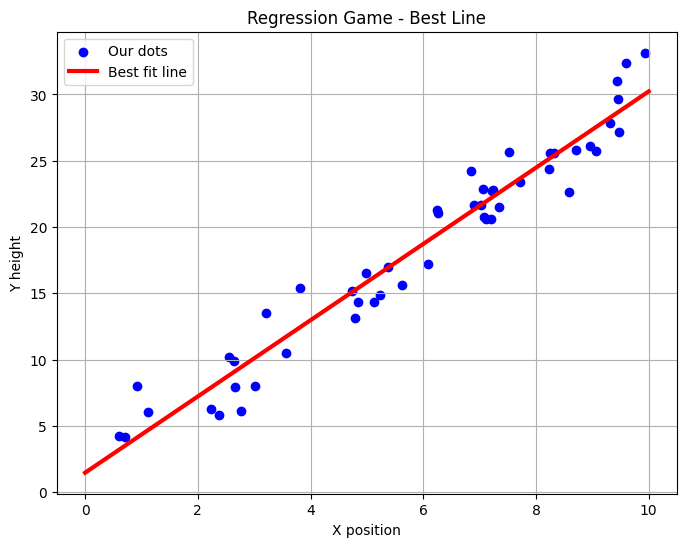

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue', label='Our dots')
x_plot = np.linspace(0, 10, 100)
y_plot = W[0] + W[1] * x_plot
plt.plot(x_plot, y_plot, color='red', linewidth=3, label='Best fit line')
plt.legend()
plt.title("Regression  - Best Line")
plt.xlabel("X position")
plt.ylabel("Y height")
plt.grid(True)
plt.show()

In [70]:
predictions = X_bias @ W
Ein = np.sum((predictions - Y) ** 2)
print("Sum of Square Error (Ein):", Ein)

Sum of Square Error (Ein): 162.72612081827197


In [71]:
np.random.seed(42)
N1 = 80
N2 = 5


cluster1 = np.random.randn(N1, 2) * 1.2 + np.array([2, 2])


cluster2 = np.random.randn(N2, 2) * 1.2 + np.array([7, 7])

X_clust = np.vstack([cluster1, cluster2])
labels = np.hstack([np.ones(N1), -np.ones(N2)]) 

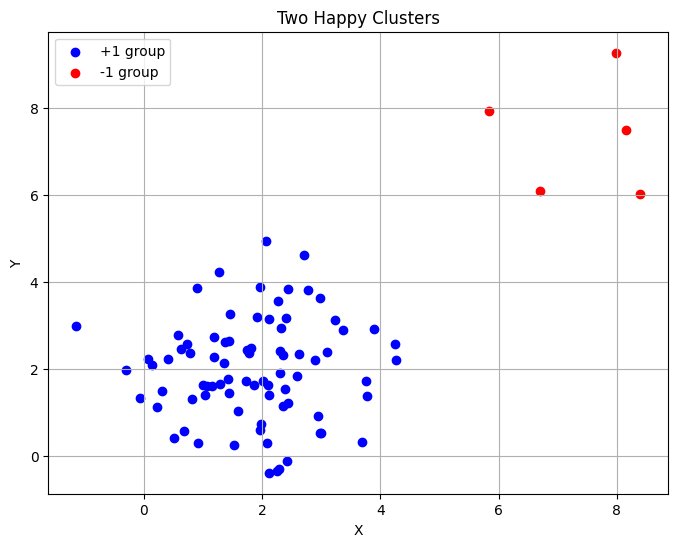

In [72]:
plt.figure(figsize=(8,6))
plt.scatter(cluster1[:,0], cluster1[:,1], color='blue', label='+1 group')
plt.scatter(cluster2[:,0], cluster2[:,1], color='red', label='-1 group')
plt.legend()
plt.title("Two Happy Clusters")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

In [73]:
X_bias_clust = np.c_[np.ones((N1+N2, 1)), X_clust]
W_class = np.linalg.pinv(X_bias_clust) @ labels.reshape(-1, 1)
print("Classification weights:", W_class.flatten())

Classification weights: [ 1.47105921 -0.14582363 -0.11777803]


In [74]:
predictions = np.sign(X_bias_clust @ W_class)   # +1 or -1
correct = np.sum(predictions.flatten() == labels)
accuracy = correct / len(labels) * 100
print(f"Accuracy: {accuracy:.1f}%")

Accuracy: 100.0%


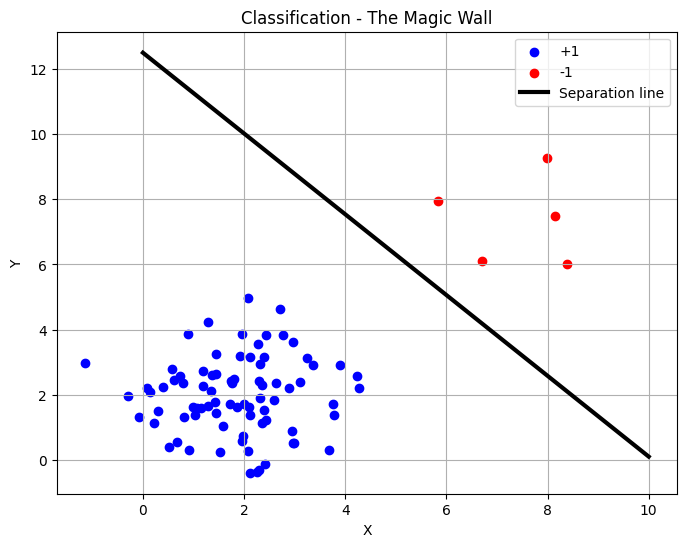

In [75]:
plt.figure(figsize=(8,6))
plt.scatter(cluster1[:,0], cluster1[:,1], color='blue', label='+1')
plt.scatter(cluster2[:,0], cluster2[:,1], color='red', label='-1')

# The line equation is w0 + w1*x + w2*y = 0
w0, w1, w2 = W_class.flatten()
if abs(w2) > 1e-8:
    x_line = np.linspace(0, 10, 100)
    y_line = (-w0 - w1 * x_line) / w2
    plt.plot(x_line, y_line, color='black', linewidth=3, label='Separation line')
else:
    plt.axvline(x=-w0/w1, color='black', linewidth=3)

plt.legend()
plt.title("Classification - The Magic Wall")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

In [76]:
# Simple Pocket Algorithm (keeps the best weights it ever saw)
def pocket_algorithm(X, y, max_iter=100):
    w = np.zeros((X.shape[1], 1))          # start with zero weights
    best_w = w.copy()
    best_errors = len(y)
    for _ in range(max_iter):
        errors = 0
        for i in range(len(y)):
            if y[i] * (X[i] @ w) <= 0:   #weight update
                w += y[i] * X[i].reshape(-1, 1)
                errors += 1
        if errors < best_errors:
            best_w = w.copy()
            best_errors = errors
    return best_w

# Use regression weights as starting point (this is the improvement!)
w_start = W_class.copy()
print("Starting with regression weights (better start!)")
w_pocket = pocket_algorithm(X_bias_clust, labels.reshape(-1, 1), max_iter=50)

Starting with regression weights (better start!)


In [77]:
np.random.seed(42)
N = 100

# +1 kids live in two places: bottom-left and top-right
pos1 = np.random.randn(N//4, 2) * 0.8 + np.array([0, 0])
pos2 = np.random.randn(N//4, 2) * 0.8 + np.array([1, 1])

# -1 kids live in the crossed places: top-left and bottom-right
neg1 = np.random.randn(N//4, 2) * 0.8 + np.array([0, 1])
neg2 = np.random.randn(N//4, 2) * 0.8 + np.array([1, 0])

X_non = np.vstack([pos1, pos2, neg1, neg2])
labels_non = np.hstack([np.ones(N//2), -np.ones(N//2)])  # +1 and -1 stickers

print("We made a tricky playground! No straight line can keep all teams apart perfectly.")

We made a tricky playground! No straight line can keep all teams apart perfectly.


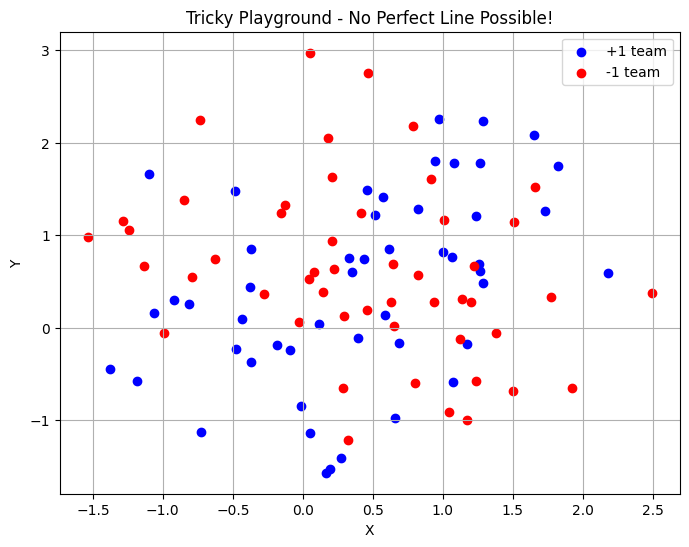

In [78]:
plt.figure(figsize=(8,6))
plt.scatter(pos1[:,0], pos1[:,1], color='blue', label='+1 team')
plt.scatter(pos2[:,0], pos2[:,1], color='blue')
plt.scatter(neg1[:,0], neg1[:,1], color='red', label='-1 team')
plt.scatter(neg2[:,0], neg2[:,1], color='red')
plt.legend()
plt.title("Tricky Playground - No Perfect Line Possible!")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

In [79]:
X_bias_non = np.c_[np.ones((N, 1)), X_non]
W_reg = np.linalg.pinv(X_bias_non) @ labels_non.reshape(-1, 1)
print("Regression gave us a smart starting wall:", W_reg.flatten())

Regression gave us a smart starting wall: [ 0.05268508 -0.01383832 -0.08923312]


In [80]:
# FIXED Pocket Algorithm - now counts REAL mistakes correctly!
def pocket_algorithm(X, y, w_start=None, max_iter=200):
    if w_start is None:
        w = np.zeros((X.shape[1], 1))          # start with nothing
    else:
        w = w_start.copy()                     # start with smart regression wall!
    
    best_w = w.copy()
    
    # Helper: count how many kids are on the wrong side RIGHT NOW
    def count_mistakes(w):
        preds = np.sign(X @ w).flatten()       # +1 or -1
        return np.sum(preds != y.flatten())
    
    best_errors = count_mistakes(w)
    
    for it in range(max_iter):
        # Baby walks through every kid once
        for i in range(len(y)):
            if y[i] * (X[i] @ w) <= 0:         # wrong side!
                w += y[i] * X[i].reshape(-1, 1)
        
        # After the walk, check how many are STILL wrong
        current_errors = count_mistakes(w)
        if current_errors < best_errors:       # pocket remembers the best wall!
            best_w = w.copy()
            best_errors = current_errors
    
    print(f"After {max_iter} tries, best mistakes left: {best_errors} (never zero because data is tricky!)")
    return best_w, best_errors

# Run version 1: start from zero (dumb baby)
print("\n=== Starting from ZERO weights ===")
w_pocket1, errors1 = pocket_algorithm(X_bias_non, labels_non.reshape(-1, 1), max_iter=200)

# Run version 2: start from regression (smart baby - this is the improvement!)
print("\n=== Starting from REGRESSION weights (the improvement!) ===")
w_pocket2, errors2 = pocket_algorithm(X_bias_non, labels_non.reshape(-1, 1), w_start=W_reg, max_iter=200)


=== Starting from ZERO weights ===
After 200 tries, best mistakes left: 43 (never zero because data is tricky!)

=== Starting from REGRESSION weights (the improvement!) ===
After 200 tries, best mistakes left: 43 (never zero because data is tricky!)


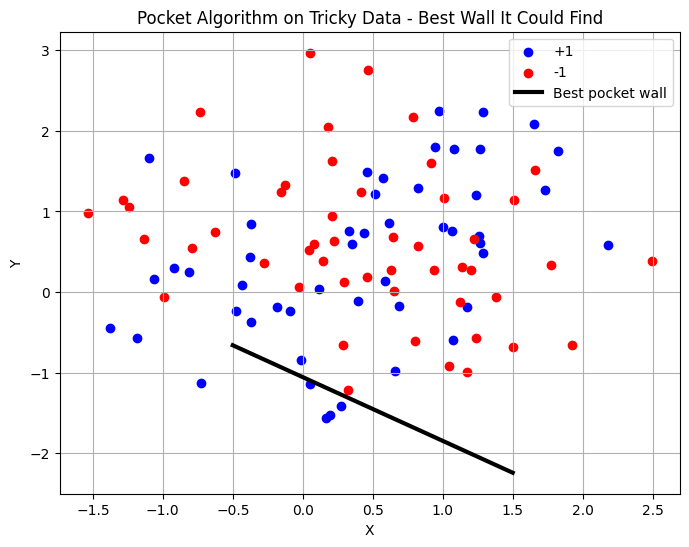

Look! The black line is the smartest wall the baby could remember.
Some kids are still on the wrong side - that's okay because the playground is impossible!


In [81]:
plt.figure(figsize=(8,6))
plt.scatter(pos1[:,0], pos1[:,1], color='blue', label='+1')
plt.scatter(pos2[:,0], pos2[:,1], color='blue')
plt.scatter(neg1[:,0], neg1[:,1], color='red', label='-1')
plt.scatter(neg2[:,0], neg2[:,1], color='red')

# Plot the best pocket wall
w0, w1, w2 = w_pocket2.flatten()
x_line = np.linspace(-0.5, 1.5, 100)
if abs(w2) > 1e-8:
    y_line = (-w0 - w1 * x_line) / w2
    plt.plot(x_line, y_line, color='black', linewidth=3, label='Best pocket wall')
else:
    plt.axvline(x=-w0/w1, color='black', linewidth=3)

plt.legend()
plt.title("Pocket Algorithm on Tricky Data - Best Wall It Could Find")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

print("Look! The black line is the smartest wall the baby could remember.")
print("Some kids are still on the wrong side - that's okay because the playground is impossible!")